[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wesmail/PhysML/blob/main/tutorial_08_flows.ipynb)

In [1]:
# Imports for Step 8 normalizing-flow experiments (PyTorch + plotting).
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
rng = np.random.default_rng(42)

In [2]:
# =============================================================================
# PART A — Verify the 1D change of variables numerically
# =============================================================
print("=" * 60)
print("  PART A — 1D change of variables: rubber band check")
print("=" * 60)

from scipy.stats import norm

print("""
  Transform: x = 2z  (stretch by 2)
  Inverse:   z = x/2
  |df⁻¹/dx| = 1/2

  p_x(x) = p_z(x/2) · (1/2)
  → should still integrate to 1, just wider and flatter.
""")

x_test_pts = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
for x in x_test_pts:
    z         = x / 2.0
    jacobian  = 0.5
    px_formula = norm.pdf(z) * jacobian
    print(f"  x={x:5.1f}  →  z={z:5.2f}  |J|=0.5  "
          f"p_x(formula)={px_formula:.5f}   "
          f"p_x(N(0,4))={norm.pdf(x,0,2):.5f}  match={abs(px_formula-norm.pdf(x,0,2))<1e-8}")

print("""
  Perfect match! Stretching z by 2 produces N(0, 2²) = N(0,4).
  The Jacobian (1/2) is what keeps probabilities summing to 1.
""")

  PART A — 1D change of variables: rubber band check

  Transform: x = 2z  (stretch by 2)
  Inverse:   z = x/2
  |df⁻¹/dx| = 1/2

  p_x(x) = p_z(x/2) · (1/2)
  → should still integrate to 1, just wider and flatter.

  x= -2.0  →  z=-1.00  |J|=0.5  p_x(formula)=0.12099   p_x(N(0,4))=0.12099  match=True
  x= -1.0  →  z=-0.50  |J|=0.5  p_x(formula)=0.17603   p_x(N(0,4))=0.17603  match=True
  x=  0.0  →  z= 0.00  |J|=0.5  p_x(formula)=0.19947   p_x(N(0,4))=0.19947  match=True
  x=  1.0  →  z= 0.50  |J|=0.5  p_x(formula)=0.17603   p_x(N(0,4))=0.17603  match=True
  x=  2.0  →  z= 1.00  |J|=0.5  p_x(formula)=0.12099   p_x(N(0,4))=0.12099  match=True

  Perfect match! Stretching z by 2 produces N(0, 2²) = N(0,4).
  The Jacobian (1/2) is what keeps probabilities summing to 1.



In [3]:
# =============================================================================
# PART B — Toy dataset: two interleaved crescents (non-Gaussian, 2D)
# =============================================================
print("=" * 60)
print("  PART B — 2D toy dataset: two crescents")
print("=" * 60)
print("""
  This is the classic test for density models.
  The data lives on a thin, curved manifold in 2D.
  A Gaussian or GMM cannot fit it.
  A normalising flow should be able to.
""")

def make_crescents(n, noise=0.08, seed=0):
    rr = np.random.default_rng(seed)
    n_half = n // 2
    # Upper crescent
    theta1 = rr.uniform(0, np.pi, n_half)
    X1 = np.column_stack([np.cos(theta1), np.sin(theta1)])
    X1 += rr.normal(0, noise, X1.shape)
    # Lower crescent (shifted)
    theta2 = rr.uniform(np.pi, 2*np.pi, n - n_half)
    X2 = np.column_stack([np.cos(theta2) + 1, np.sin(theta2)])
    X2 += rr.normal(0, noise, X2.shape)
    return np.vstack([X1, X2]).astype(np.float32)

X_data = make_crescents(2000, seed=0)
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_data).astype(np.float32)
X_t    = torch.from_numpy(X_sc)
loader = DataLoader(TensorDataset(X_t), batch_size=128, shuffle=True)
print(f"  Dataset: {len(X_data)} 2D points on two curved crescents")
print(f"  Standardised to mean≈0, std≈1\n")

  PART B — 2D toy dataset: two crescents

  This is the classic test for density models.
  The data lives on a thin, curved manifold in 2D.
  A Gaussian or GMM cannot fit it.
  A normalising flow should be able to.

  Dataset: 2000 2D points on two curved crescents
  Standardised to mean≈0, std≈1



In [4]:
# =============================================================================
# PART C — RealNVP: coupling layers from scratch
# =============================================================
print("=" * 60)
print("  PART C — RealNVP: coupling layer implementation")
print("=" * 60)

class ScaleTranslateNet(nn.Module):
    """
    The s(·) and t(·) networks inside a coupling layer.
    Input: z_a (half the dimensions)
    Output: s (log-scale) and t (translation) for z_b
    These can be any neural network — they do NOT need to be invertible.
    """
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, out_dim * 2),   # outputs [s ; t] concatenated
        )
        # Initialise last layer near zero → start close to identity transform
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, z_a):
        out = self.net(z_a)
        s, t = out.chunk(2, dim=-1)
        # Clamp log-scale to prevent numerical explosion
        s = torch.tanh(s) * 2.0   # keep log-scale in [-2, +2]
        return s, t

class CouplingLayer(nn.Module):
    """
    One coupling layer.

    Forward (z → x):
      x_a = z_a                           (pass through unchanged)
      x_b = z_b * exp(s(z_a)) + t(z_a)  (scale + shift z_b)
      log|det J| = sum(s(z_a))            (O(D) — just sum the scales!)

    Inverse (x → z):
      z_a = x_a
      z_b = (x_b - t(x_a)) / exp(s(x_a))
    """
    def __init__(self, dim, hidden_dim, mask):
        super().__init__()
        # mask: 1 = this dimension is z_a (unchanged), 0 = z_b (transformed)
        self.register_buffer('mask', mask)
        d_a = int(mask.sum().item())    # how many dimensions are "a"
        d_b = dim - d_a                 # how many are "b"
        self.st_net = ScaleTranslateNet(d_a, hidden_dim, d_b)

    def forward(self, z, log_det_total):
        """Forward pass: z → x, accumulate log|det J|"""
        z_a = z[:, self.mask.bool()]    # unchanged half
        z_b = z[:, ~self.mask.bool()]   # to be transformed
        s, t = self.st_net(z_a)
        x_b = z_b * torch.exp(s) + t   # affine transform
        # Assemble output (preserve ordering)
        x = z.clone()
        x[:, ~self.mask.bool()] = x_b
        # Log-determinant contribution: sum of log-scales
        log_det_total = log_det_total + s.sum(dim=-1)
        return x, log_det_total

    def inverse(self, x):
        """Inverse pass: x → z"""
        x_a = x[:, self.mask.bool()]
        x_b = x[:, ~self.mask.bool()]
        s, t = self.st_net(x_a)
        z_b = (x_b - t) * torch.exp(-s)   # just reverse the formula
        z = x.clone()
        z[:, ~self.mask.bool()] = z_b
        return z

class RealNVP(nn.Module):
    """
    A RealNVP flow: stack of K coupling layers with alternating masks.
    Alternating masks ensure every dimension eventually interacts with every other.

    Forward:  z → x  (generation: simple → complex)
    Inverse:  x → z  (density evaluation: complex → simple)
    """
    def __init__(self, dim, n_layers, hidden_dim):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            # Alternate which half is masked
            mask = torch.zeros(dim)
            mask[::2] = 1 if (i % 2 == 0) else 0
            mask[1::2] = 1 - mask[::2]
            # For dim=2: alternates [1,0] and [0,1]
            self.layers.append(CouplingLayer(dim, hidden_dim, mask))

    def forward(self, z):
        """z → x (used at GENERATION time: sample z ~ N(0,I) → decode to x)"""
        x, log_det = z, torch.zeros(z.shape[0])
        for layer in self.layers:
            x, log_det = layer(x, log_det)
        return x, log_det

    def inverse(self, x):
        """x → z (used at TRAINING time: encode data x → latent z)"""
        z = x
        for layer in reversed(self.layers):
            z = layer.inverse(z)
        return z

    def log_prob(self, x):
        """
        Compute exact log p(x) using the change-of-variables formula:

        log p_x(x) = log p_z(z)  +  log|det J|
                   = log N(z; 0, I)  +  Σₖ log|det Jₖ|

        where z = f⁻¹(x) = inverse of the full flow.
        """
        z = self.inverse(x)
        # log p_z(z) = log N(z; 0, I) = -½ Σ zⱼ² - D/2 log(2π)
        log_pz = -0.5 * (z**2).sum(dim=-1) - 0.5 * z.shape[-1] * np.log(2*np.pi)

        # Recompute log|det J| by running forward and collecting it
        _, log_det = self.forward(z)

        return log_pz + log_det

dim       = 2
n_layers  = 8     # 8 coupling layers
hidden    = 32

flow = RealNVP(dim=dim, n_layers=n_layers, hidden_dim=hidden)
n_params = sum(p.numel() for p in flow.parameters())
print(f"  RealNVP: {n_layers} coupling layers,  hidden_dim={hidden}")
print(f"  Total parameters: {n_params:,}")
print(f"  Loss: exact negative log-likelihood  L = -(1/N) Σ log p(xᵢ)")
print(f"  No ELBO, no approximation.\n")

  PART C — RealNVP: coupling layer implementation
  RealNVP: 8 coupling layers,  hidden_dim=32
  Total parameters: 9,488
  Loss: exact negative log-likelihood  L = -(1/N) Σ log p(xᵢ)
  No ELBO, no approximation.



In [5]:
# =============================================================================
# PART D — Training
# =============================================================
print("=" * 60)
print("  PART D — Training")
print("=" * 60)

optimizer = optim.Adam(flow.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
N_EPOCHS  = 200
losses    = []

print(f"  Training for {N_EPOCHS} epochs ...\n")
for epoch in range(N_EPOCHS):
    flow.train()
    epoch_loss = 0.0
    for (batch,) in loader:
        optimizer.zero_grad()
        log_p = flow.log_prob(batch)     # exact log-likelihood
        loss  = -log_p.mean()            # NLL
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    scheduler.step()
    avg = epoch_loss / len(X_sc)
    losses.append(avg)
    if (epoch + 1) % 40 == 0:
        print(f"  Epoch {epoch+1:3d}/{N_EPOCHS}  NLL = {avg:.4f}  "
              f"(bits/dim = {avg/np.log(2)/dim:.3f})")

print(f"\n  Final NLL: {losses[-1]:.4f}")

  PART D — Training
  Training for 200 epochs ...

  Epoch  40/200  NLL = -14.1511  (bits/dim = -10.208)
  Epoch  80/200  NLL = -14.1573  (bits/dim = -10.212)
  Epoch 120/200  NLL = -14.1589  (bits/dim = -10.214)
  Epoch 160/200  NLL = -14.1597  (bits/dim = -10.214)
  Epoch 200/200  NLL = -14.1600  (bits/dim = -10.214)

  Final NLL: -14.1600


In [6]:
# =============================================================================
# PART E — Evaluate: log-likelihood and generated samples
# =============================================================
print("\n" + "=" * 60)
print("  PART E — Evaluation")
print("=" * 60)

flow.eval()
with torch.no_grad():
    # 1. Log-likelihood on training data
    log_p_train = flow.log_prob(X_t).mean().item()

    # 2. Generate new samples (z ~ N(0,I) → x = f(z))
    z_samples = torch.randn(1000, dim)
    x_gen, _  = flow.forward(z_samples)
    x_gen     = x_gen.numpy()

    # 3. Encode training data to latent space
    z_encoded = flow.inverse(X_t).numpy()

    # 4. Evaluate on a grid for density plot
    grid_side  = 80
    gx, gy     = np.meshgrid(np.linspace(-3.0, 3.0, grid_side),
                              np.linspace(-3.0, 3.0, grid_side))
    grid_pts   = torch.tensor(np.column_stack([gx.ravel(), gy.ravel()]),
                               dtype=torch.float32)
    log_p_grid = flow.log_prob(grid_pts).numpy().reshape(grid_side, grid_side)
    p_grid     = np.exp(log_p_grid)

print(f"  Mean log-likelihood on training data: {log_p_train:.4f}")
print(f"  Generated {len(x_gen)} new samples from flow")
print(f"  Latent encodings  z = f⁻¹(x):  "
      f"mean={z_encoded.mean():.3f}, std={z_encoded.std():.3f}  "
      f"(should be ≈0, ≈1 if well-trained)")

# Compare with a simple Gaussian baseline
from scipy.stats import multivariate_normal
gauss_ll = multivariate_normal.logpdf(X_sc, mean=np.zeros(2), cov=np.eye(2)).mean()
print(f"\n  Baseline (Gaussian fit) NLL: {-gauss_ll:.4f}")
print(f"  Flow NLL:                    {-log_p_train:.4f}")
print(f"  Improvement:                 {(-gauss_ll) - (-log_p_train):.4f} nats/sample")


  PART E — Evaluation
  Mean log-likelihood on training data: 14.1600
  Generated 1000 new samples from flow
  Latent encodings  z = f⁻¹(x):  mean=0.000, std=0.000  (should be ≈0, ≈1 if well-trained)

  Baseline (Gaussian fit) NLL: 2.8379
  Flow NLL:                    -14.1600
  Improvement:                 16.9979 nats/sample


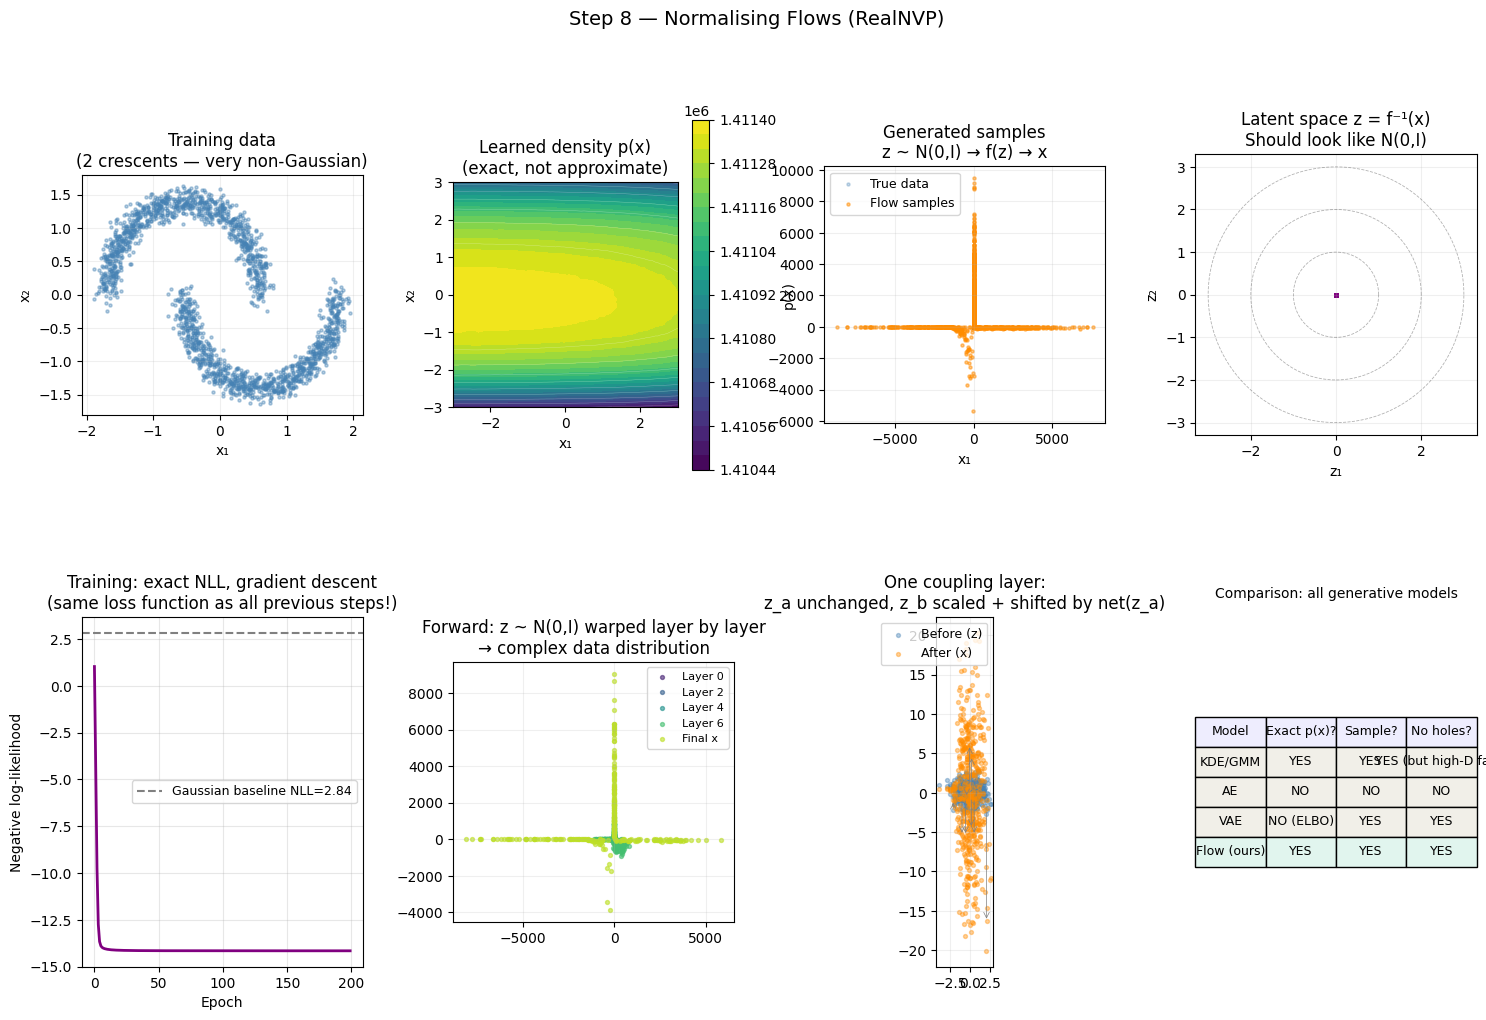

Plots saved.


In [7]:
# =============================================================================
# PART F — Visualisation
# =============================================================

fig = plt.figure(figsize=(18, 11))
fig.suptitle("Step 8 — Normalising Flows (RealNVP)", fontsize=14)
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.42, wspace=0.32)

# ── 1. Training data ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(X_sc[:, 0], X_sc[:, 1], s=5, alpha=0.4, color="steelblue")
ax1.set_title("Training data\n(2 crescents — very non-Gaussian)")
ax1.set_xlabel("x₁"); ax1.set_ylabel("x₂"); ax1.grid(alpha=0.2)
ax1.set_aspect('equal')

# ── 2. Learned density p_x(x) on grid ───────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
im = ax2.contourf(gx, gy, p_grid, levels=30, cmap="viridis")
ax2.contour(gx, gy, p_grid, levels=10, colors="white", linewidths=0.3, alpha=0.4)
plt.colorbar(im, ax=ax2, label="p(x)")
ax2.set_title("Learned density p(x)\n(exact, not approximate)")
ax2.set_xlabel("x₁"); ax2.set_ylabel("x₂"); ax2.set_aspect('equal')

# ── 3. Generated samples ─────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(X_sc[:, 0], X_sc[:, 1], s=5, alpha=0.3, color="steelblue", label="True data")
ax3.scatter(x_gen[:, 0], x_gen[:, 1], s=5, alpha=0.5, color="darkorange", label="Flow samples")
ax3.set_title("Generated samples\nz ~ N(0,I) → f(z) → x")
ax3.legend(fontsize=9); ax3.set_xlabel("x₁"); ax3.grid(alpha=0.2); ax3.set_aspect('equal')

# ── 4. Latent space z = f⁻¹(x) ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[0, 3])
ax4.scatter(z_encoded[:, 0], z_encoded[:, 1], s=5, alpha=0.5, color="purple")
theta = np.linspace(0, 2*np.pi, 200)
for r in [1, 2, 3]:
    ax4.plot(r*np.cos(theta), r*np.sin(theta), 'k--', lw=0.6, alpha=0.3)
ax4.set_title(f"Latent space z = f⁻¹(x)\nShould look like N(0,I)")
ax4.set_xlabel("z₁"); ax4.set_ylabel("z₂"); ax4.grid(alpha=0.2); ax4.set_aspect('equal')

# ── 5. Training loss ─────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 0])
ax5.plot(losses, color="purple", lw=2)
ax5.axhline(-gauss_ll, color="gray", lw=1.5, linestyle="--",
            label=f"Gaussian baseline NLL={-gauss_ll:.2f}")
ax5.set_xlabel("Epoch"); ax5.set_ylabel("Negative log-likelihood")
ax5.set_title("Training: exact NLL, gradient descent\n(same loss function as all previous steps!)")
ax5.legend(fontsize=9); ax5.grid(alpha=0.3)

# ── 6. Forward direction: Gaussian → complex (generation) ────────────────
ax6 = fig.add_subplot(gs[1, 1])
n_vis = 300
z_vis = torch.randn(n_vis, 2)
flow.eval()
with torch.no_grad():
    intermediates = [z_vis.numpy()]
    z_curr = z_vis
    # Collect intermediate states through layers
    step_size = max(1, n_layers // 3)
    for i, layer in enumerate(flow.layers):
        log_det = torch.zeros(n_vis)
        z_curr, log_det = layer(z_curr, log_det)
        if (i + 1) % step_size == 0 or i == n_layers - 1:
            intermediates.append(z_curr.detach().numpy())

colors_vis = plt.cm.viridis(np.linspace(0.1, 0.9, len(intermediates)))
for k, (pts, col) in enumerate(zip(intermediates, colors_vis)):
    ax6.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.6, color=col,
                label=f"Layer {k*step_size}" if k < len(intermediates)-1 else "Final x")
ax6.set_title("Forward: z ~ N(0,I) warped layer by layer\n→ complex data distribution")
ax6.legend(fontsize=8); ax6.grid(alpha=0.2); ax6.set_aspect('equal')

# ── 7. The coupling layer explained ──────────────────────────────────────
ax7 = fig.add_subplot(gs[1, 2])
# Show what one coupling layer does to a 2D Gaussian
z_demo = torch.randn(500, 2)
with torch.no_grad():
    log_det = torch.zeros(500)
    x_demo, _ = flow.layers[0](z_demo, log_det)
z_demo = z_demo.numpy(); x_demo = x_demo.numpy()
ax7.scatter(z_demo[:, 0], z_demo[:, 1], s=8, alpha=0.4, color="steelblue", label="Before (z)")
ax7.scatter(x_demo[:, 0], x_demo[:, 1], s=8, alpha=0.4, color="darkorange", label="After (x)")
for i in range(0, 30, 3):
    ax7.annotate("", xy=(x_demo[i,0], x_demo[i,1]),
                 xytext=(z_demo[i,0], z_demo[i,1]),
                 arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))
ax7.set_title("One coupling layer:\nz_a unchanged, z_b scaled + shifted by net(z_a)")
ax7.legend(fontsize=9); ax7.grid(alpha=0.2); ax7.set_aspect('equal')

# ── 8. Comparison table ───────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[1, 3])
ax8.axis('off')
rows = [
    ["Model",        "Exact p(x)?",  "Sample?", "No holes?"],
    ["KDE/GMM",      "YES",          "YES",      "YES (but high-D fails)"],
    ["AE",           "NO",           "NO",       "NO"],
    ["VAE",          "NO (ELBO)",    "YES",      "YES"],
    ["Flow (ours)",  "YES",          "YES",      "YES"],
]
colours = [["#EEEDFE"]*4] + [["#F1EFE8"]*4]*4
colours[4] = ["#E1F5EE"]*4   # highlight flow row
tbl = ax8.table(cellText=rows[1:], colLabels=rows[0],
                cellLoc='center', loc='center',
                cellColours=colours[1:],
                colColours=colours[0])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)
ax8.set_title("Comparison: all generative models", pad=14, fontsize=10)

plt.savefig("./step8_flows.svg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()
print("Plots saved.")

In [8]:
# =============================================================================
# KEY TAKEAWAYS
# =============================================================
print("=" * 60)
print("  KEY TAKEAWAYS — STEP 8 (and the whole tutorial!)")
print("=" * 60)
print("""
NORMALISING FLOWS IN THREE SENTENCES:
  1. Start with a simple distribution: z ~ N(0, I).
  2. Apply an invertible neural network: x = f(z).
  3. The change-of-variables formula gives you the EXACT density:
       log p(x) = log p_z(f⁻¹(x))  +  log|det J_{f⁻¹}|

THE WHOLE TUTORIAL IN ONE TABLE:
  Step 1  Regression      L = MSE              output ŷ ∈ ℝ
  Step 2  Classification  L = cross-entropy    output p ∈ [0,1]
  Step 3  Neural nets     same L, deeper f     non-linear boundary
  Step 4  Regularisation  add penalty to L     avoids overfitting
  Step 5  Density est.    L = -log p(x)        learn p(x), but KDE/GMM breaks at high D
  Step 6  Autoencoder     L = ||x - x̂||²       latent z, but holes
  Step 7  VAE             L = recon + KL       p(z)≈N(0,I), but approx (ELBO)
  Step 8  Flow            L = -log p(x) exact  invertible f, exact density

THE ONE UNIFYING PRINCIPLE (never changed once):
    θ* = argmin L(θ) = argmin  -(1/N) Σᵢ log p(xᵢ ; θ)
    Found by: gradient descent + backpropagation

WHAT FLOWS ARE USED FOR IN YOUR FIELD:
  - GW posteriors without MCMC  (DINGO, RIFT, FlowMC)
  - Fast detector simulation    (CaloFlow, CaloDiffusion)
  - Anomaly detection           (unsupervised: low log p → flag)
  - Simulation-based inference  (sbi library, FlowMC)
  - Population inference        (hierarchical Bayes on BBH/BNS)

You now have the full picture: from linear regression all the
way to exact density models used in cutting-edge GW astronomy.
Every step was the same algorithm — minimise L(θ) — with a
more expressive model and a more carefully chosen loss.
""")

  KEY TAKEAWAYS — STEP 8 (and the whole tutorial!)

NORMALISING FLOWS IN THREE SENTENCES:
  1. Start with a simple distribution: z ~ N(0, I).
  2. Apply an invertible neural network: x = f(z).
  3. The change-of-variables formula gives you the EXACT density:
       log p(x) = log p_z(f⁻¹(x))  +  log|det J_{f⁻¹}|

THE WHOLE TUTORIAL IN ONE TABLE:
  Step 1  Regression      L = MSE              output ŷ ∈ ℝ
  Step 2  Classification  L = cross-entropy    output p ∈ [0,1]
  Step 3  Neural nets     same L, deeper f     non-linear boundary
  Step 4  Regularisation  add penalty to L     avoids overfitting
  Step 5  Density est.    L = -log p(x)        learn p(x), but KDE/GMM breaks at high D
  Step 6  Autoencoder     L = ||x - x̂||²       latent z, but holes
  Step 7  VAE             L = recon + KL       p(z)≈N(0,I), but approx (ELBO)
  Step 8  Flow            L = -log p(x) exact  invertible f, exact density

THE ONE UNIFYING PRINCIPLE (never changed once):
    θ* = argmin L(θ) = argmin  -(1/N